In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer
# rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1

In [2]:
traits = {
    'cOPN': 'Openness',
    'cEXT': 'Extraversion',
    'cNEU': 'Neuroticism',
    'cAGR': 'Agreeableness',	
    'cCON': 'Conscientiousness'
}

In [ ]:
df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
edf = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_openai_embedded.csv' )
liwc_df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/processed_data/LIWC_pandora_to_big5_v4.csv' )
df.shape, edf.shape, liwc_df.shape

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [34]:
ldf = liwc_df[['STATUS', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']]
ddf = df[['STATUS']]

In [46]:
df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
ddf = df[['STATUS']]
ddf

,STATUS
0,That sounds amazing. The hate levels of 2016 w...
1,&amp;nbsp;You should post pictures (if you're ...
2,I agree with this 100%! I felt like I was tryi...
3,"Sorry PabloMarinus, your submission has been r..."
4,"Interesting… but honestly, it's a formality, i..."
...,...
93506,I went from Nike loyalty to Asics due to some ...
93507,At this point I think goats is being played mo...
93508,"You're lying, but OK. Not really, but keep usi..."
93509,"The thing is, they never actually forget that ..."


In [48]:

rdf = pd.merge(ddf, edf, left_on='STATUS', right_on='body', how='left') 
rdf = pd.merge(rdf, ldf, left_on='body', right_on='STATUS', how='left')
rdf.shape
# ldf = rdf.loc[:, ~rdf.columns.str.contains('^Unnamed')]
# ldf.drop(['STATUS', 'openai_embedding', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)

# rdf['openai_embedding'] = rdf['openai_embedding'].apply(eval).apply(np.array)
# ldf.to_csv(f'data/{target}_ldf.csv')
# emb_np = rdf['openai_embedding'].tolist()
# np.save(f'data/{target}_emb.npy', emb_np)

(93511, 67)

In [49]:
emotion_df = rdf[['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']]


In [50]:
emb_np = rdf['openai_embedding'].apply(eval).apply(np.array).tolist()
eedf = pd.DataFrame(emb_np)
# np.save(f'data/all_emb.npy', emb_np)
print(eedf.shape, emotion_df.shape)


(93511, 1536) (93511, 10)


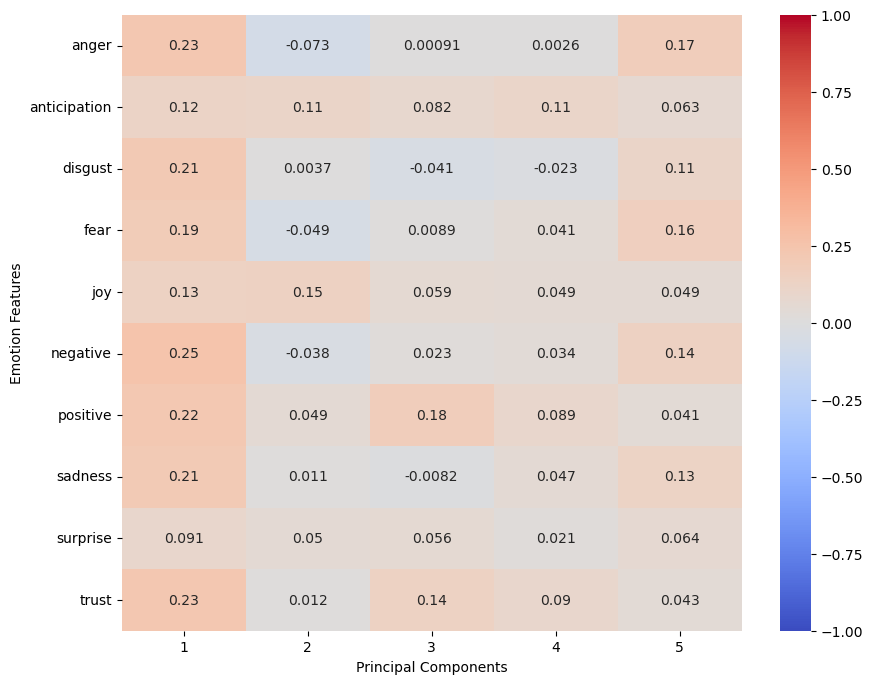

In [53]:
n_components = 6
for i in range(5, n_components, 1):
    pca = PCA(n_components=i)
    re = pca.fit_transform(eedf)
    redf = pd.DataFrame(re)
    redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

    final_df = pd.concat([emotion_df, redf], axis=1)
    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[emotion_df.columns, redf.columns]

    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # plt.title('Emotion correlation ')
    plt.xlabel(f'Principal Components')
    plt.ylabel(f'Emotion Features')
    plt.savefig(f'iteration/emotions_{i}_final.png', bbox_inches='tight')
    plt.show()

In [24]:
eedf

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
0,-0.015766,0.030355,-0.016770,0.009830,0.050859,0.007274,-0.006244,0.018791,0.025215,-0.002521,...,-0.035628,0.048182,-0.054071,0.031746,0.017198,0.014575,0.017372,-0.023716,0.002222,0.027089
1,0.002951,0.000834,-0.080585,0.091150,-0.004008,-0.023635,-0.054297,0.004634,-0.004275,0.051594,...,-0.038253,0.024704,0.000481,-0.009262,0.006108,0.043020,0.022493,-0.009539,-0.003255,0.004868
2,0.042979,0.000641,-0.047140,0.046113,0.028073,-0.038687,0.007519,0.031760,0.014432,0.015564,...,-0.032234,0.013787,-0.014103,-0.004951,0.002948,0.020607,0.037686,-0.031892,0.029232,0.022069
3,-0.009947,0.021413,0.013224,-0.020552,-0.032258,0.024390,0.018669,0.015925,-0.010013,0.038943,...,-0.029674,0.040198,0.003178,-0.015881,-0.015866,0.010852,0.002651,-0.015779,-0.014210,0.008699
4,-0.020017,-0.019607,-0.045911,0.024593,0.031377,-0.037138,-0.016537,-0.002155,-0.011690,0.050941,...,0.002467,0.002429,-0.043045,-0.027971,-0.026596,-0.003568,0.024505,-0.003926,-0.014482,0.038893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935097,-0.018034,0.002879,0.043092,-0.012911,0.012016,-0.023573,0.008059,0.033791,0.015660,-0.008600,...,0.000141,-0.006990,-0.016604,-0.024975,0.005754,0.004620,-0.010495,-0.015229,0.011419,0.000947
935098,0.017899,0.047412,-0.001854,-0.000020,0.011868,0.009298,-0.001885,0.031370,0.019293,0.030736,...,-0.045678,0.005346,0.002472,-0.011458,0.003619,-0.000322,0.016754,0.008222,-0.026508,0.004757
935099,-0.030939,0.039712,0.026236,0.003391,-0.039190,0.002821,0.050823,-0.029839,0.034954,-0.003341,...,-0.009811,0.008058,0.002365,-0.008773,0.007054,0.018344,0.012761,-0.014878,-0.004273,0.011379
935100,0.011791,0.025546,0.014935,-0.006582,0.006160,-0.016555,-0.003861,0.019424,0.006524,0.030584,...,-0.014633,0.010844,-0.020069,0.005247,-0.010268,-0.024914,-0.003548,-0.017310,-0.012876,0.003981


In [36]:
ldf = pd.read_csv(f'data/{target}_ldf.csv')
emb_np = np.load(f'data/{target}_emb.npy')  # Load your embeddings
eedf = pd.DataFrame(emb_np)
eedf.columns = [f'e_{i}' for i in range(1536)]
eedf.shape, ldf.shape, target

((24591, 1536), (24591, 134), 'cCON')

In [37]:
scaler = StandardScaler()
esdf = scaler.fit_transform(eedf)
scaler = StandardScaler()
lsdf = scaler.fit_transform(ldf)


In [2]:

# fa = FactorAnalyzer(n_factors=5, rotation='varimax')
# fa.fit(esdf)
# factor_loadings = fa.loadings_
# print(factor_loadings)

# # np.save('ext_factor_loadings.npy', factor_loadings)
# import numpy as np
# factor_loadings = np.load('ext_factor_loadings.npy')  # Load your embeddings
# print(factor_loadings.shape)
# # Plot factor loadings
# plt.figure(figsize=(10, 6))
# plt.imshow(factor_loadings, cmap='viridis', aspect='auto')
# plt.colorbar()
# plt.title('Factor Loadings')
# plt.xlabel('Factors')
# plt.ylabel('Embedding Dimensions')
# plt.show()

(1536, 2)


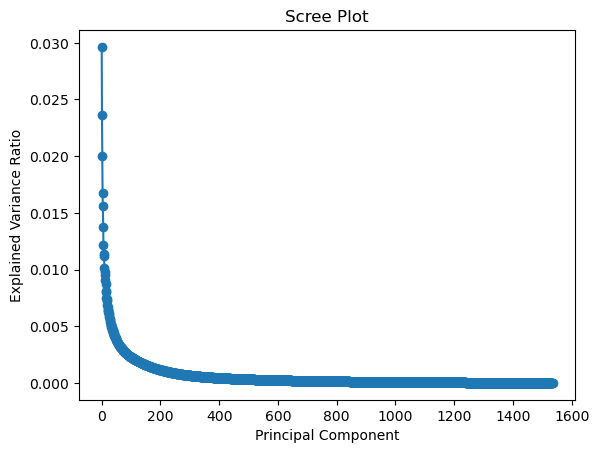

In [38]:
pca = PCA(n_components=None)
pca.fit(esdf)

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# plt.plot(cumulative_variance, marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Cumulative Explained Variance')
# plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
# plt.legend()
# plt.show()

# eigenvalues = pca.explained_variance_
# ideal_dim = sum(eigenvalues > 1)
# print(f"Ideal dimensions (Kaiser Criterion): {ideal_dim}")

In [39]:
pca = PCA(n_components=5)
re = pca.fit_transform(esdf)
redf = pd.DataFrame(re)
redf.columns = [f'{i}' for i in range(redf.shape[1])]
lsdf.shape, redf.shape

((24591, 134), (24591, 5))

In [40]:
from sklearn.linear_model import Lasso
X = np.array(lsdf)  
y = np.array(redf)  
# Fit Lasso for each embedding dimension
lasso = Lasso(alpha=0.01)  
lasso.fit(X, y[:, 0])  
coefficients = lasso.coef_
key_features = []

for i in range(y.shape[1]):
    lasso = Lasso(alpha=0.5)  # Adjust alpha as needed
    lasso.fit(X, y[:, i])
    coefficients = lasso.coef_
    key_features.append(coefficients)

liwc_feature_names = ldf.columns

# Get non-zero coefficients for the first embedding dimension
non_zero_indices = np.where(coefficients != 0)[0]
key_liwc_features = [liwc_feature_names[i] for i in non_zero_indices]
print("Key LIWC Features:", key_liwc_features)

Key LIWC Features: ['Authentic', 'i', 'shehe', 'cogproc', 'tone_neg', 'conflict', 'Culture', 'politic', 'leisure', 'work', 'money', 'health', 'substances', 'food', 'space', 'time', 'focuspresent', 'anger', 'Arousal']


Highly Important LIWC Features: ['Authentic', 'i', 'shehe', 'cogproc', 'tone_neg', 'conflict', 'Culture', 'politic', 'leisure', 'work', 'money', 'health', 'substances', 'food', 'space', 'time', 'focuspresent', 'anger', 'Arousal']


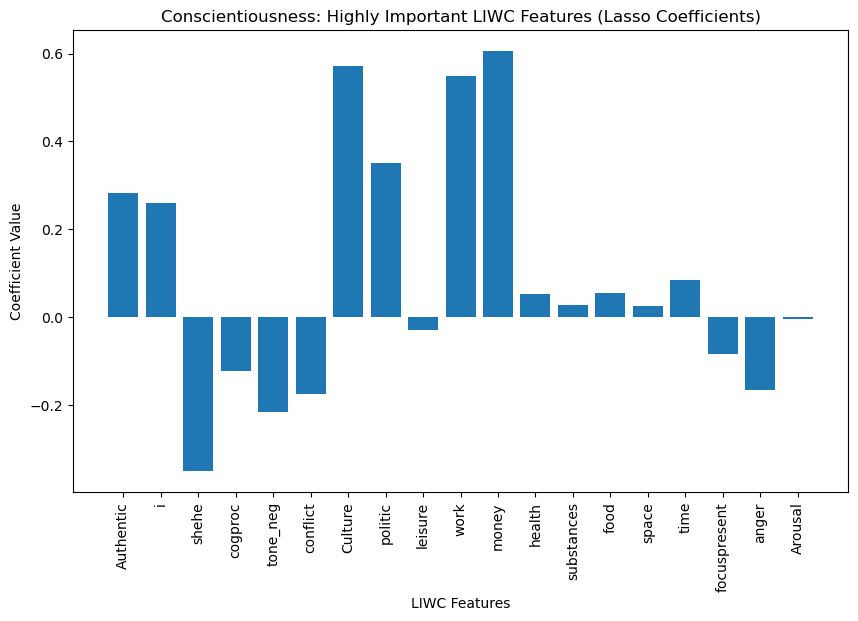

In [41]:

# plt.figure(figsize=(10, 6))
# plt.bar(range(len(coefficients)), coefficients)
# plt.xticks(range(len(coefficients)), liwc_feature_names, rotation=90)
# plt.xlabel("LIWC Features")
# plt.ylabel("Coefficient Value")
# plt.title("Lasso Coefficients for LIWC Features")
# plt.show()

# Assuming `coefficients` is the array of Lasso coefficients
highly_important_indices = np.where(np.abs(coefficients) > 0)[0]
highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]

print("Highly Important LIWC Features:", highly_important_features)

plt.figure(figsize=(10, 6))
plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
plt.xlabel("LIWC Features")
plt.ylabel("Coefficient Value")
plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
# plt.savefig(f'{target}_liwc.png')
plt.show()

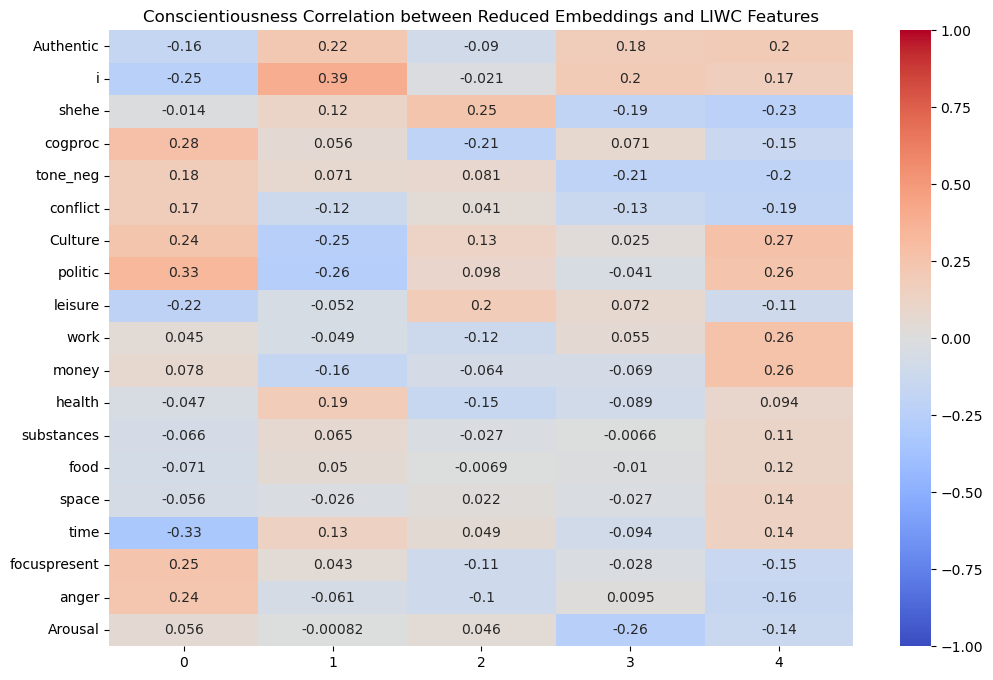

In [42]:
final_df = pd.concat([ldf[key_liwc_features], redf], axis=1)
# Compute correlation matrix
correlation_matrix = final_df.corr(method='pearson') 
embedding_liwc_corr = correlation_matrix.loc[key_liwc_features, redf.columns]


plt.figure(figsize=(12, 8))
sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
# plt.savefig(f'{target}.png')
plt.show()